# Thorough evaluation

The two **display modes** are scored first, at the resolution you see:

- **Short** — day model, hourly, next 24h
- **Medium** — week model, 6-hourly, next 7 days

Year hold-out and quarterly walk-forward then retrain the week model as a deeper backtest.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from energy_forecast.forecast import prepare_history
from energy_forecast.model import load_day_models, load_hour_models, load_models
from energy_forecast import evaluate

importlib.reload(evaluate)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

In [2]:
week_frame = prepare_history()
hour_frame = prepare_history(weather_source="archive")
week_models = load_models()
day_models = load_day_models()
hour_models = load_hour_models()
print("week", week_frame["timestamp"].min(), "->", week_frame["timestamp"].max(), "n=", len(week_frame))
print("hour", hour_frame["timestamp"].min(), "->", hour_frame["timestamp"].max(), "n=", len(hour_frame))

week 2024-01-01 00:00:00+00:00 -> 2026-09-19 23:30:00+01:00 n= 381296
hour 2021-01-01 00:00:00+00:00 -> 2026-09-25 11:00:00+01:00 n= 100485


## Forecast modes

Same last-eight-week holdout as training. Metrics are computed after resampling to hourly (short) or 6-hourly (medium).

**RMSSE** is RMSE divided by the RMSE of a weekly seasonal naive on the training history (`< 1` beats last-week-same-hour). **WRMSSE** is that scaled error weighted by demand in each time-of-day band, so evening peak counts more than night.

In [3]:
mode_metrics, mode_scored = evaluate.score_forecast_modes(
    week_frame, week_models, day_models
)
mode_metrics

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,short,2690,827.20,"1,114.47",0.04,-155.03,206.80,413.60,190.70,0.79,"2,778.58",0.49
1,medium,1792,900.26,"1,224.00",0.04,-176.69,219.19,450.13,215.10,0.91,"3,949.66",0.42


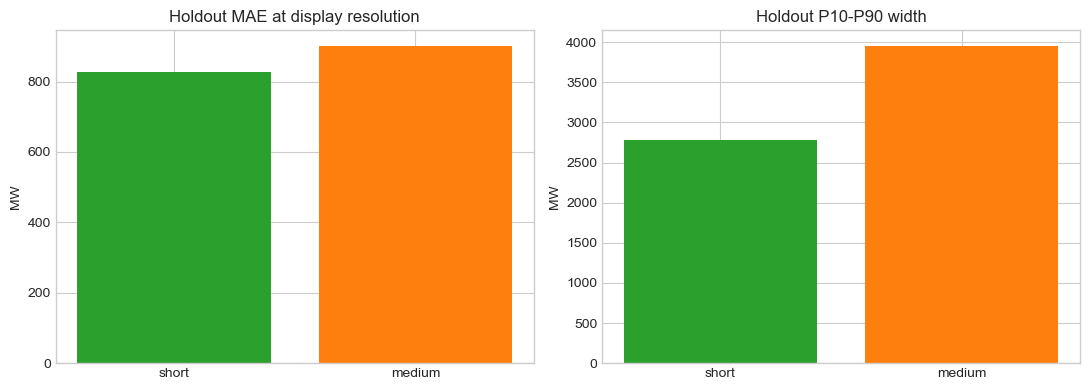

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
shown = mode_metrics.set_index("split").reindex(["short", "medium"]).dropna(how="all")
axes[0].bar(shown.index, shown["mae"], color=["tab:green", "tab:orange"])
axes[0].set_title("Holdout MAE at display resolution")
axes[0].set_ylabel("MW")
axes[1].bar(shown.index, shown["interval_width"], color=["tab:green", "tab:orange"])
axes[1].set_title("Holdout P10-P90 width")
axes[1].set_ylabel("MW")
plt.tight_layout()
plt.show()

## Short term — hourly, 24h

n= 2690


,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,all,2690,827.20,"1,114.47",0.04,-155.03,206.80,413.60,190.70,0.79,"2,778.58",0.49


By season


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,season,autumn,912,996.64,"1,288.82",0.04,-77.86,228.16,498.32,213.75,0.73,"2,856.02",0.32
1,season,summer,1778,740.29,"1,013.47",0.04,-194.61,195.83,370.14,178.88,0.83,"2,738.86",0.57


By period band


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,period_band,afternoon,448,"1,344.79","1,663.31",0.07,-745.82,349.00,672.40,273.68,0.64,"3,598.72",0.47
1,period_band,evening_peak,448,805.27,"1,031.55",0.03,-167.07,185.42,402.64,194.54,0.86,"3,024.89",0.45
2,period_band,late_evening,450,511.08,660.88,0.02,110.05,137.75,255.54,131.79,0.92,"2,515.75",0.54
3,period_band,morning,672,993.51,"1,292.40",0.05,-383.94,243.56,496.75,238.42,0.74,"3,077.68",0.41
4,period_band,night,672,542.12,674.76,0.03,298.27,135.72,271.06,124.56,0.81,"1,944.51",0.61


By weekday


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,weekday,weekday,1920,820.79,"1,104.32",0.04,-180.33,204.63,410.40,190.49,0.80,"2,844.73",0.47
1,weekday,weekend,770,843.17,"1,139.39",0.04,-91.92,212.19,421.59,191.23,0.77,"2,613.63",0.54


By holiday


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,holiday,holiday,48,892.06,"1,041.60",0.04,-189.76,128.60,446.03,188.59,0.96,"2,975.59",0.58
1,holiday,normal,2642,826.02,"1,115.75",0.04,-154.39,208.22,413.01,190.74,0.79,"2,775.00",0.49


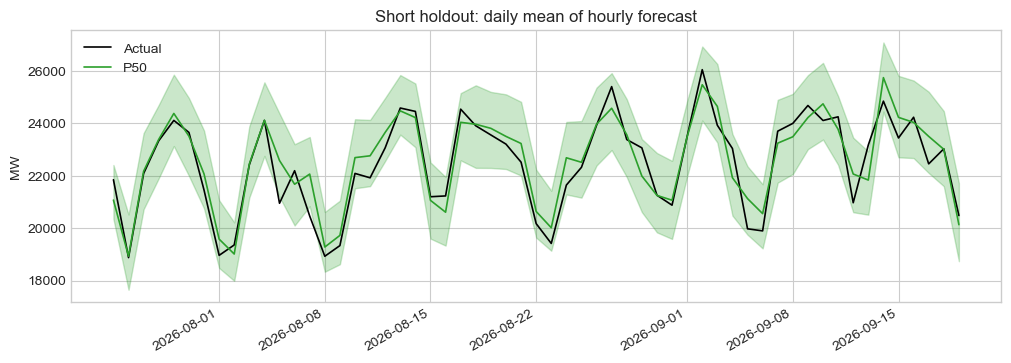

In [5]:
short_scored = mode_scored["short"]
print("n=", len(short_scored))
display(evaluate.overall_metrics(short_scored))
print("By season")
display(evaluate.slice_metrics(short_scored, "season"))
print("By period band")
display(evaluate.slice_metrics(short_scored, "period_band"))
print("By weekday")
display(evaluate.slice_metrics(short_scored, "weekday"))
print("By holiday")
if "holiday" in short_scored.columns:
    display(evaluate.slice_metrics(short_scored, "holiday"))

short_daily = evaluate.daily_metrics(short_scored)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(short_daily["date"], short_daily["demand_mw"], color="black", linewidth=1.2, label="Actual")
ax.plot(short_daily["date"], short_daily["p50"], color="tab:green", linewidth=1.2, label="P50")
ax.fill_between(short_daily["date"], short_daily["p10"], short_daily["p90"], color="tab:green", alpha=0.25)
ax.set_title("Short holdout: daily mean of hourly forecast")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

## Medium term — 6-hourly, 7 days

In [ ]:
medium_scored = mode_scored["medium"]
print("n=", len(medium_scored))
display(evaluate.overall_metrics(medium_scored))
print("By season")
display(evaluate.slice_metrics(medium_scored, "season"))
print("By period band")
display(evaluate.slice_metrics(medium_scored, "period_band"))
print("By weekday")
display(evaluate.slice_metrics(medium_scored, "weekday"))
print("By holiday")
if "holiday" in medium_scored.columns:
    display(evaluate.slice_metrics(medium_scored, "holiday"))
if "lead_band" in medium_scored.columns:
    print("By lead")
    display(evaluate.slice_metrics(medium_scored, "lead_band"))

medium_daily = evaluate.daily_metrics(medium_scored)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(medium_daily["date"], medium_daily["demand_mw"], color="black", linewidth=1.2, label="Actual")
ax.plot(medium_daily["date"], medium_daily["p50"], color="tab:orange", linewidth=1.2, label="P50")
ax.fill_between(medium_daily["date"], medium_daily["p10"], medium_daily["p90"], color="tab:orange", alpha=0.25)
ax.set_title("Medium holdout: daily mean of 6-hourly forecast")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(medium_daily["date"], medium_daily["interval_width"], color="tab:orange", linewidth=2, label="Medium")
ax.plot(short_daily["date"], short_daily["interval_width"], color="tab:green", linewidth=2, label="Short")
ax.set_title("Holdout interval width by mode")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

## Year hold-out

Train on all earlier years and test each later calendar year. The last split is the most recent year (2026 INDO). The production model trained on the full history is not used here.

In [8]:
year_metrics, year_scored = evaluate.year_holdout(week_frame)
year_metrics

,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,train 2024-2024 -> 2025,140160,"1,169.13","1,614.28",0.05,-110.08,399.37,584.56,378.64,0.94,"7,201.52",0.39
1,train 2024-2025 -> 2026,100592,"1,166.68","1,605.28",0.05,-176.67,331.73,583.34,326.57,0.92,"5,917.04",0.35


In [9]:
honest_key = list(year_scored)[-1]
print("Slicing", honest_key)
honest = year_scored[honest_key]
print("By season")
display(evaluate.slice_metrics(honest, "season"))
print("By month")
display(evaluate.slice_metrics(honest, "month"))
print("By period band")
display(evaluate.slice_metrics(honest, "period_band"))
print("By weekday")
display(evaluate.slice_metrics(honest, "weekday"))
print("By holiday")
display(evaluate.slice_metrics(honest, "holiday"))
print("By lead")
if "lead_band" in honest.columns:
    display(evaluate.slice_metrics(honest, "lead_band"))
print("By horizon")
if "horizon" in honest.columns:
    display(evaluate.slice_metrics(honest, "horizon"))
print("By temperature")
display(evaluate.slice_metrics(honest, "temp_band"))

Slicing train 2024-2025 -> 2026
By season


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,season,autumn,7296,"1,173.51","1,577.54",0.05,-243.53,307.51,586.75,329.30,0.94,"6,052.79",0.21
1,season,spring,35312,"1,252.93","1,758.64",0.05,-189.43,354.87,626.46,349.53,0.92,"6,204.71",0.31
2,season,summer,35328,"1,051.47","1,458.02",0.05,-311.24,286.28,525.74,299.93,0.92,"5,280.25",0.38
3,season,winter,22656,"1,209.70","1,582.65",0.04,74.61,374.32,604.85,331.45,0.92,"6,417.91",0.38


By month


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,month,1,11904,"1,197.33","1,510.09",0.04,20.68,362.21,598.66,328.67,0.92,"6,231.87",0.37
1,month,2,10752,"1,223.40","1,659.28",0.04,134.32,387.74,611.70,334.53,0.93,"6,623.88",0.40
2,month,3,11888,"1,433.79","1,977.62",0.05,127.85,421.54,716.90,378.88,0.91,"6,930.21",0.25
3,month,4,11520,"1,326.15","1,898.65",0.06,-595.57,332.36,663.07,375.40,0.90,"6,163.61",0.31
4,month,5,11904,"1,001.44","1,334.25",0.05,-113.26,310.06,500.72,295.18,0.93,"5,519.96",0.38
5,month,6,11520,983.62,"1,359.22",0.05,-73.02,307.17,491.81,299.47,0.93,"5,549.72",0.32
6,month,7,11904,"1,118.79","1,563.41",0.06,-654.73,271.99,559.39,318.01,0.91,"5,108.15",0.41
7,month,8,11904,"1,049.82","1,441.09",0.05,-198.29,280.37,524.91,282.30,0.92,"5,191.57",0.40
8,month,9,7296,"1,173.51","1,577.54",0.05,-243.53,307.51,586.75,329.30,0.94,"6,052.79",0.21


By period band


...

,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,lead_band,0-24h,25148,"1,041.56","1,398.28",0.04,-132.18,273.34,520.78,264.84,0.89,"4,475.93",0.42
1,lead_band,24-72h,25148,"1,081.00","1,470.96",0.05,-104.72,296.00,540.50,285.36,0.90,"5,031.46",0.39
2,lead_band,72-168h,50296,"1,272.08","1,759.10",0.05,-234.88,378.78,636.04,378.04,0.95,"7,080.38",0.29


By horizon


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,horizon,next_day,12574,"1,059.58","1,424.80",0.05,-139.35,278.37,529.79,269.95,0.89,"4,579.12",0.41
1,horizon,next_hour,12574,"1,023.54","1,371.26",0.04,-125.00,268.30,511.77,259.73,0.88,"4,372.74",0.43
2,horizon,next_week,75444,"1,208.38","1,668.59",0.05,-191.50,351.19,604.19,347.15,0.93,"6,397.40",0.32


By temperature


,slice,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,temp_band,cold,27986,"1,143.41","1,594.70",0.04,2.18,359.53,571.71,332.64,0.94,"6,353.78",0.26
1,temp_band,freezing,11890,"1,276.60","1,607.03",0.04,178.33,376.23,638.30,324.75,0.89,"6,184.74",0.41
2,temp_band,hot,13390,"1,332.36","1,734.72",0.07,-619.29,318.43,666.18,355.43,0.87,"5,678.72",0.39
3,temp_band,mild,22407,"1,159.81","1,679.78",0.05,-232.44,320.77,579.90,329.97,0.93,"5,907.10",0.32
4,temp_band,warm,24919,"1,057.52","1,469.68",0.05,-258.92,296.26,528.76,302.07,0.93,"5,435.80",0.38


In [10]:
daily = evaluate.daily_metrics(honest)
best, worst = evaluate.best_worst_days(daily, n=12)
print("Best days (lowest daily MAE)")
display(best)
print("Worst days (highest daily MAE)")
display(worst)

Best days (lowest daily MAE)


,date,year,season,mae,bias,mape,coverage,demand_mw,p50,temperature_2m
150,2026-05-31,2026,spring,394.23,-1.18,0.02,1.00,"19,222.19","19,223.36",17.02
157,2026-06-07,2026,summer,495.38,-295.43,0.03,1.00,"19,230.58","19,526.02",14.56
201,2026-07-21,2026,summer,509.68,-186.12,0.02,0.99,"23,213.38","23,399.49",18.93
165,2026-06-15,2026,summer,511.28,-5.59,0.02,0.99,"22,759.31","22,764.90",16.89
21,2026-01-22,2026,winter,530.82,-150.09,0.02,1.00,"32,472.56","32,622.66",6.95
22,2026-01-23,2026,winter,530.88,-55.45,0.02,1.00,"31,665.77","31,721.22",6.38
180,2026-06-30,2026,summer,532.49,-139.93,0.02,0.99,"23,621.10","23,761.04",17.73
127,2026-05-08,2026,spring,535.70,197.61,0.02,1.00,"24,240.00","24,042.39",11.96
231,2026-08-20,2026,summer,540.39,-329.86,0.02,0.99,"23,205.10","23,534.96",15.50
126,2026-05-07,2026,spring,540.86,282.61,0.02,1.00,"25,322.54","25,039.93",9.94


Worst days (highest daily MAE)


,date,year,season,mae,bias,mape,coverage,demand_mw,p50,temperature_2m
182,2026-07-02,2026,summer,"2,876.40","-2,826.91",0.17,0.43,"19,485.29","22,312.21",17.75
95,2026-04-06,2026,spring,"2,596.42",-930.04,0.14,0.46,"22,022.19","22,952.23",8.21
216,2026-08-05,2026,summer,"2,523.96","-2,523.96",0.12,0.72,"20,950.71","23,474.67",18.29
64,2026-03-06,2026,spring,"2,481.36","2,445.78",0.07,0.76,"31,046.60","28,600.83",7.30
87,2026-03-29,2026,spring,"2,435.59","1,653.96",0.09,0.72,"25,886.50","24,232.54",6.96
94,2026-04-05,2026,spring,"2,393.39","-2,227.66",0.13,0.78,"20,300.83","22,528.50",7.78
86,2026-03-28,2026,spring,"2,284.65","-1,940.27",0.11,0.69,"23,237.31","25,177.58",6.30
75,2026-03-17,2026,spring,"2,250.84","-1,555.09",0.09,0.75,"26,135.69","27,690.78",10.29
72,2026-03-14,2026,spring,"2,169.43",-818.71,0.09,0.54,"26,009.94","26,828.65",5.58
110,2026-04-21,2026,spring,"2,149.30","-2,108.17",0.10,0.79,"23,759.23","25,867.40",8.46


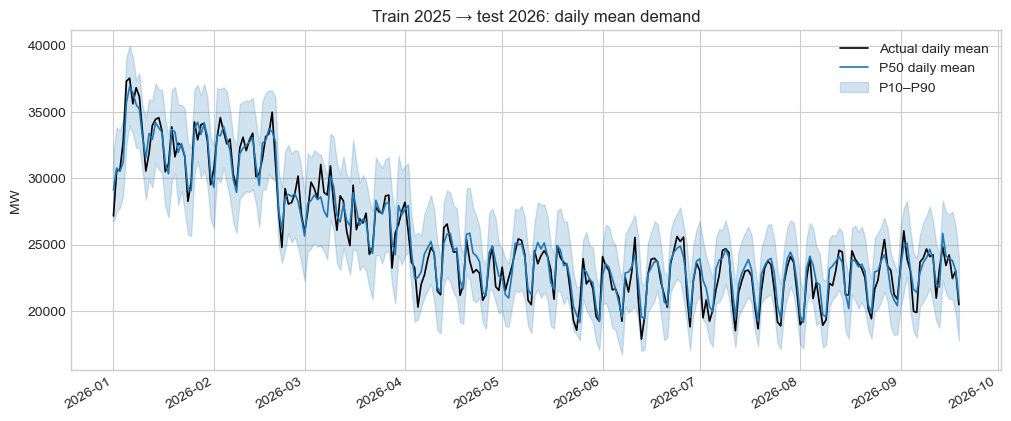

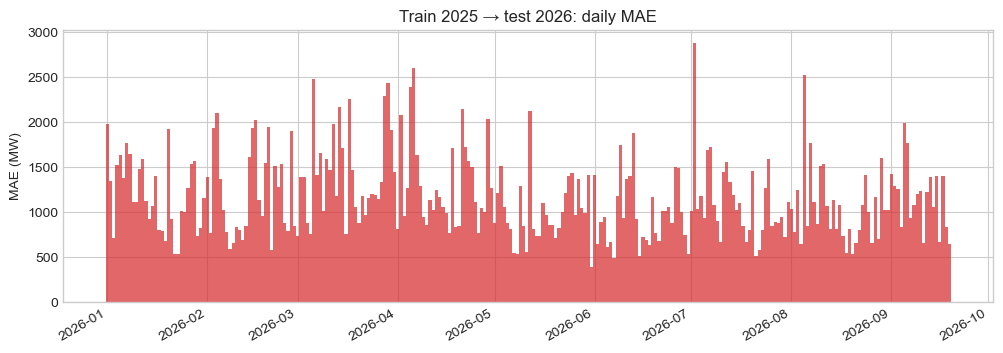

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["date"], daily["demand_mw"], color="black", linewidth=1.2, label="Actual daily mean")
ax.plot(daily["date"], daily["p50"], color="tab:blue", linewidth=1.2, label="P50 daily mean")
ax.fill_between(daily["date"], daily["p10"], daily["p90"], color="tab:blue", alpha=0.2, label="P10–P90")
ax.set_title("Train 2025 → test 2026: daily mean demand")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(daily["date"], daily["mae"], color="tab:red", width=1.0, alpha=0.7)
ax.set_title("Train 2025 → test 2026: daily MAE")
ax.set_ylabel("MAE (MW)")
fig.autofmt_xdate()
plt.show()

## Expanding quarterly walk-forward

Train on all history up to quarter *t*, test quarter *t+1*.

In [12]:
wf_metrics, wf_scored = evaluate.walk_forward_quarters(week_frame)
wf_metrics

D:\energy-forecast\src\energy_forecast\evaluate.py:196: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  period = pd.to_datetime(work["timestamp"], utc=True).dt.to_period("Q")


,split,n,mae,rmse,mape,bias,pinball_10,pinball_50,pinball_90,coverage_80,interval_width,skill_vs_climatology
0,2024Q1-2024Q1 -> 2024Q2,34944,"1,521.22","2,004.26",0.07,"-1,017.03",363.99,760.61,341.81,0.78,"4,770.90",NaN
1,2024Q1-2024Q2 -> 2024Q3,35328,"1,115.16","1,530.92",0.05,170.60,308.15,557.58,294.10,0.84,"4,672.01",NaN
2,2024Q1-2024Q3 -> 2024Q4,35328,"1,252.93","1,618.21",0.04,495.70,346.50,626.47,304.50,0.83,"5,027.87",NaN
3,2024Q1-2024Q4 -> 2025Q1,34560,"1,296.73","1,741.16",0.04,182.64,474.51,648.36,440.26,0.94,"8,486.19",0.48
4,2024Q1-2025Q1 -> 2025Q2,34944,"1,128.03","1,578.86",0.05,-412.75,288.33,564.01,256.53,0.80,"3,807.05",0.36
5,2024Q1-2025Q2 -> 2025Q3,35328,"1,006.63","1,429.17",0.05,-202.24,284.48,503.32,280.36,0.92,"4,969.79",0.31
6,2024Q1-2025Q3 -> 2025Q4,35328,"1,145.54","1,585.24",0.04,-0.65,320.10,572.77,253.14,0.80,"3,799.84",0.39
7,2024Q1-2025Q4 -> 2026Q1,34560,"1,282.18","1,719.16",0.04,79.11,383.57,641.09,342.92,0.92,"6,534.16",0.34
8,2024Q1-2026Q1 -> 2026Q2,34944,"1,097.98","1,546.88",0.05,-282.72,295.46,548.99,292.34,0.88,"4,857.78",0.34
9,2024Q1-2026Q2 -> 2026Q3,31088,"1,054.55","1,468.11",0.05,-380.10,256.39,527.27,252.44,0.86,"4,099.70",0.39


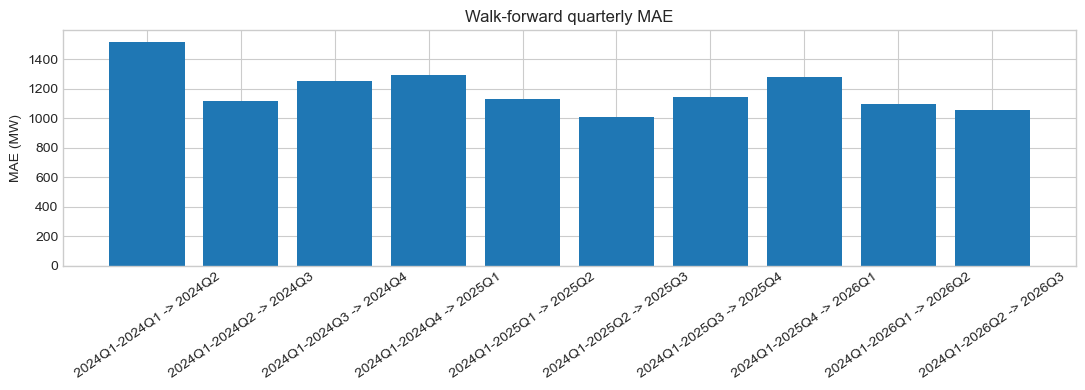

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(wf_metrics["split"], wf_metrics["mae"])
ax.set_title("Walk-forward quarterly MAE")
ax.set_ylabel("MAE (MW)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()